# efdr-jumps — Construction chronologique du projet

## Objectif scientifique

Ce projet implémente une bibliothèque Python de recherche qui (i) simule des trajectoires de log-prix intraday sous plusieurs DGP saut-diffusion (Heston+Merton, Heston+Hawkes), (ii) calcule des estimateurs de volatilité spot *jump-robust* (MedRV, MinRV, bipower, threshold-BV, pré-moyennage), (iii) construit des e-processus valides pour l'hypothèse « pas de saut au temps i » à partir de ces estimateurs, (iv) exécute des algorithmes de FDR en ligne sur le stream d'e-valeurs (e-LOND, e-LORD, e-SAFFRON, stopped e-BH, e-BH offline et baselines BH-LM / BH-BNS), et (v) évalue le FDR empirique et la puissance sur une grille Monte Carlo calibrée. Le projet reproduit et étend Yen (2013) et Bajgrowicz-Scaillet (2016) avec la méthodologie e-values / e-FDR de l'école Ramdas 2022–2026.

## Dépendances entre modules

```
simulate/
  heston.py   ──┐
  merton.py   ──┤  (hérite HestonSimulator)
  hawkes.py   ──┤  (hérite HestonSimulator)
  noise.py    ──┘
       │
       ▼
estimators/                evalues/
  bipower.py                construct.py
  medrv_minrv.py  ──────►  (r_i, σ̂_i)  ──────►  fdr/
  threshold.py                                      ebh.py
  spot.py         ──────►  σ̂²(i)                    elond.py
  preavg.py                                          elord_esaffron.py
                                                      stopped_ebh.py
                                                      baselines.py
                                                          │
                                                          ▼
                                                    pipeline/
                                                      detector.py
                                                      metrics.py
```

## Table des matières

- [Section 0 — Imports](#section-0)
- [Section 1 — Étape 1 : Bootstrap](#section-1)
- [Section 2 — Étape 2 : Simulateurs](#section-2)
- [Section 3 — Étape 3 : Estimateurs](#section-3)
- [Section 4 — Étape 4 : E-values](#section-4)
- [Section 5 — Étape 6 : Algorithmes FDR](#section-5)
- [Section 6 — Étape 7 : Pipeline orchestrateur](#section-6)
- [Section 7 — Étape 8 : Grille Monte Carlo](#section-7)
- [Section 8 — Architecture finale](#section-8)
- [Section 9 — Ce qui reste et bibliographie](#section-9)

In [1]:
from __future__ import annotations

import os
import time
import subprocess

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

from efdr_jumps.simulate import (
    HestonSimulator, MertonSimulator, HawkesSimulator, NoisyPath,
    SimulationResult, SECS_PER_YEAR,
)
from efdr_jumps.estimators import (
    bipower_variation, bns_ratio_stat, lee_mykland_stat, realized_variance,
    medrv, minrv, threshold_rv, spot_variance, preavg_bv,
)
from efdr_jumps.evalues.construct import construct_evalue
from efdr_jumps.fdr import ebh, bh_lee_mykland, bh_bns, elond, elord, esaffron, stopped_ebh
from efdr_jumps.pipeline import (
    run_detector, SimulatorConfig, EstimatorConfig, FDRConfig, DetectorResult,
    fdp, power, f1_score, detection_delays, rejection_rate, aggregate,
)

np.random.seed(0)

os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Palette commune pour les 7 algos
ALGO_COLORS = {
    'ebh': '#1f77b4',
    'stopped_ebh': '#aec7e8',
    'elond': '#2ca02c',
    'elord': '#d62728',
    'esaffron': '#ff7f0e',
    'bh_lm': '#9467bd',
    'bh_bns': '#8c564b',
}

print('Imports OK — efdr-jumps chargé avec succès.')

Imports OK — efdr-jumps chargé avec succès.


> **Note :** Ce notebook retrace la *construction* du projet étape par étape, en exécutant le vrai code à chaque brique. Il ne présente pas les résultats finaux du projet (voir `03_results_figures.ipynb` pour ça, une fois `grid_main.parquet` disponible). L'objectif est pédagogique : montrer comment chaque module a été construit, validé, et pourquoi les décisions techniques ont été prises dans cet ordre.

<a id='section-1'></a>
## Section 1 — Étape 1 : Bootstrap du repo

| | |
|---|---|
| **Commits clés** | `183d7a7` — Initial commit (2026-05-16 02:01) |
| **Objectif** | Poser la structure du repo : packaging, CI, pre-commit, squelette vide. Aucun algorithme n'est implémenté à ce stade — juste l'infrastructure qui permettra à tout le reste de fonctionner. |

### Fichiers créés

| Fichier | Rôle |
|---|---|
| `pyproject.toml` | Deps (numpy, scipy, numba, matplotlib, pandas, pyyaml, joblib) + config ruff/black/pytest |
| `.github/workflows/ci.yml` | CI GitHub Actions : lint + tests sur chaque push |
| `.pre-commit-config.yaml` | Hooks pre-commit : ruff, black, no large files |
| `EXECUTION_PLAN.md` | Plan en 10 étapes — source de vérité pour l'ordre d'implémentation |
| `CLAUDE (1).md` | Conventions, stack, acceptance criteria |
| Squelettes `src/`, `tests/` | Package vide installable |

In [2]:
# Arborescence du repo (fichiers clés)
result = subprocess.run(
    ['find', '..', '-not', '-path', '*/__pycache__/*', '-not', '-path', '*/.git/*',
     '-not', '-path', '*/.*', '-not', '-path', '*/results/*',
     '-name', '*.py', '-o', '-name', '*.toml', '-o', '-name', '*.yaml', '-o', '-name', '*.md'],
    capture_output=True, text=True
)
paths = sorted(p for p in result.stdout.strip().split('\n') if p and '.ipynb_checkpoints' not in p)
for p in paths:
    print(p.replace('../', ''))

.pre-commit-config.yaml
.pytest_cache/README.md
CLAUDE (1).md
DECISIONS.md
EXECUTION_PLAN.md
PROJECT_REPORT.md
data/README.md
experiments/02_power_grid.py
experiments/configs/grid_main.yaml
experiments/configs/grid_medium.yaml
experiments/configs/grid_quick.yaml
pyproject.toml
src/efdr_jumps/__init__.py
src/efdr_jumps/estimators/__init__.py
src/efdr_jumps/estimators/bipower.py
src/efdr_jumps/estimators/medrv_minrv.py
src/efdr_jumps/estimators/preavg.py
src/efdr_jumps/estimators/spot.py
src/efdr_jumps/estimators/threshold.py
src/efdr_jumps/evalues/__init__.py
src/efdr_jumps/evalues/construct.py
src/efdr_jumps/fdr/__init__.py
src/efdr_jumps/fdr/baselines.py
src/efdr_jumps/fdr/ebh.py
src/efdr_jumps/fdr/elond.py
src/efdr_jumps/fdr/elord_esaffron.py
src/efdr_jumps/fdr/stopped_ebh.py
src/efdr_jumps/pipeline/__init__.py
src/efdr_jumps/pipeline/detector.py
src/efdr_jumps/pipeline/metrics.py
src/efdr_jumps/simulate/__init__.py
src/efdr_jumps/simulate/base.py
src/efdr_jumps/simulate/hawkes.py
sr

In [3]:
# Contenu de pyproject.toml — montre les dépendances exactes
with open('../pyproject.toml') as f:
    print(f.read())

# Tailles des fichiers infrastructure
print('\n--- Tailles (lignes) ---')
infra_files = [
    '../pyproject.toml', '../.github/workflows/ci.yml',
    '../.pre-commit-config.yaml',
]
for fp in infra_files:
    try:
        with open(fp) as f:
            n = sum(1 for _ in f)
        print(f'{n:4d}  {fp.replace("../", "")}')
    except FileNotFoundError:
        print(f'  --  {fp} (non trouvé)')

[build-system]
requires = ["setuptools>=42", "wheel"]
build-backend = "setuptools.build_meta"

[project]
name = "efdr-jumps"
version = "0.1.0"
description = "Online FDR control for high-frequency jump detection in financial semimartingales"
requires-python = ">=3.9"
dependencies = [
    "numpy>=1.26",
    "scipy>=1.12",
    "numba>=0.59",
    "matplotlib>=3.8",
    "pandas>=2.2",
    "pyyaml>=6.0",
    "joblib>=1.3",
]

[project.optional-dependencies]
dev = [
    "pytest>=8.0",
    "pytest-cov>=5.0",
    "ruff>=0.4",
    "black>=24.0",
    "pre-commit>=3.7",
]

[tool.setuptools.packages.find]
where = ["src"]

[tool.pytest.ini_options]
testpaths = ["tests"]
addopts = "-q --tb=short"
markers = ["slow: marks tests as slow (deselect with '-m not slow')"]

[tool.ruff]
src = ["src"]
line-length = 100

[tool.ruff.lint]
select = ["E", "F", "W", "I", "UP"]

[tool.black]
line-length = 100
target-version = ["py311"]


--- Tailles (lignes) ---
  46  pyproject.toml
  28  .github/workflows/ci.yml
  

**Critère d'exit :** `pip install -e .` fonctionne, `pytest` exit 0 (zéro tests), `ruff check .` passe. — Rempli dans le commit initial.

<a id='section-2'></a>
## Section 2 — Étape 2 : Simulateurs

| | |
|---|---|
| **Commits clés** | `183d7a7` — Initial commit (inclut Étapes 1-5) |
| **Objectif** | Simuler des trajectoires de log-prix intraday sous Heston (diffusion pure), Heston+Merton (sauts Poisson), Heston+Hawkes (sauts auto-excitants), avec ou sans bruit microstructure. Exposer les indices de saut exacts comme vérité terrain. |

### Fichiers créés

| Fichier | Lignes | Rôle |
|---|---|---|
| `simulate/base.py` | 36 | `PathSimulator` ABC, `SimulationResult` dataclass, `SECS_PER_YEAR` |
| `simulate/heston.py` | 143 | Schéma QE d'Andersen (2008) pour Heston SV |
| `simulate/merton.py` | 81 | Heston + sauts Poisson-Merton (Andersen-Benzoni-Lund 2002) |
| `simulate/hawkes.py` | 104 | Heston + sauts Hawkes auto-excitants (Étape 8) |
| `simulate/noise.py` | 59 | Bruit microstructure additif gaussien ou one-sided Exp (Bibinger 2024) |

In [4]:
# Tailles des modules simulate/
simulate_files = [
    '../src/efdr_jumps/simulate/base.py',
    '../src/efdr_jumps/simulate/heston.py',
    '../src/efdr_jumps/simulate/merton.py',
    '../src/efdr_jumps/simulate/hawkes.py',
    '../src/efdr_jumps/simulate/noise.py',
]
for fp in simulate_files:
    with open(fp) as f:
        n = sum(1 for _ in f)
    print(f'{n:4d}  {fp.split("/")[-1]}')

  36  base.py
 143  heston.py
  81  merton.py
 104  hawkes.py
  59  noise.py


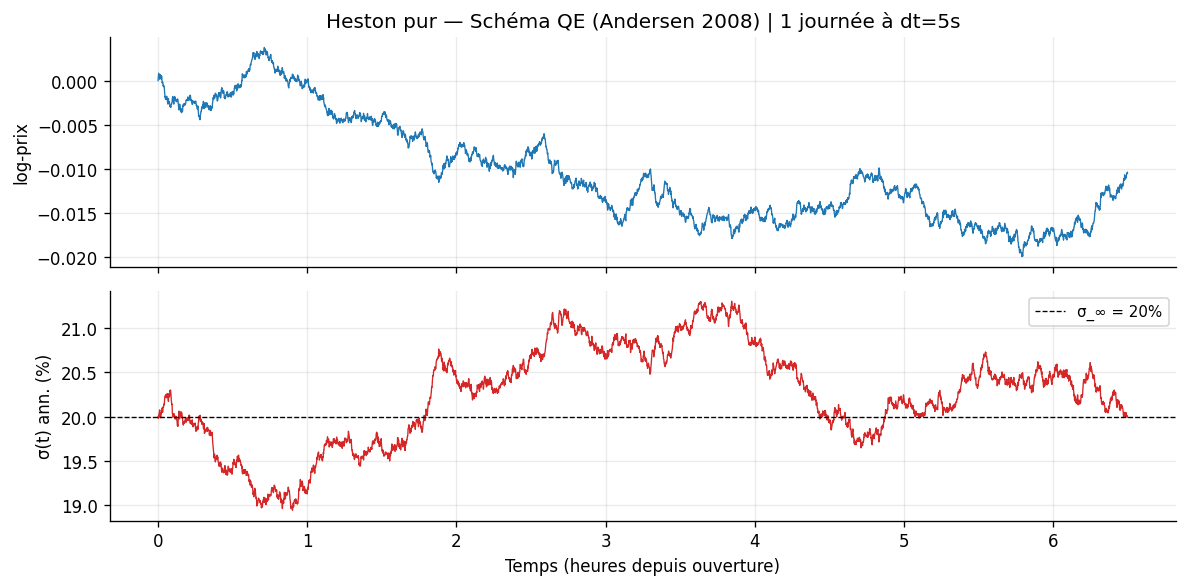

n_steps=4680 | σ_initial=20.0% | σ_final=20.0%


In [5]:
# ── Démo 2a : Heston pur — log-prix et vol stochastique ──────────────────────
rng = np.random.default_rng(42)
heston = HestonSimulator(kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, v0=0.04)
res_h = heston.simulate(n_steps=4680, dt_seconds=5.0, rng=rng)  # ~6.5h à 5s

t_hours = res_h.times / 3600  # en heures

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t_hours, res_h.log_price, lw=0.8, color='#1f77b4')
axes[0].set_ylabel('log-prix')
axes[0].set_title('Heston pur — Schéma QE (Andersen 2008) | 1 journée à dt=5s')

axes[1].plot(t_hours, res_h.sigma_path * 100, lw=0.8, color='#d62728')
axes[1].set_ylabel('σ(t) ann. (%)')
axes[1].set_xlabel('Temps (heures depuis ouverture)')
axes[1].axhline(np.sqrt(0.04) * 100, ls='--', color='k', lw=0.8, label='σ_∞ = 20%')
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/section2a_heston_path.pdf', bbox_inches='tight')
plt.show()
print(f'n_steps={len(res_h.log_price)-1} | σ_initial={res_h.sigma_path[0]*100:.1f}% | σ_final={res_h.sigma_path[-1]*100:.1f}%')

In [ ]:
# ── Démo 2b : Heston+Merton avec sauts marqués + histogramme incréments ──────
rng2 = np.random.default_rng(7)
dt_s = 5.0
dt_y = dt_s / SECS_PER_YEAR
sigma_base = np.sqrt(0.04)  # ≈ 0.20
mu_j = 5.0 * sigma_base * np.sqrt(dt_y)  # jump size = 5σ√dt

# lambda=30 000/an → E[sauts] ≈ 12.7 sur 500 pas → sauts clairement visibles
merton = MertonSimulator(
    heston=HestonSimulator(kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, v0=0.04),
    lam=30000.0, mu_j=mu_j, sigma_j=0.1 * abs(mu_j)
)
res_m = merton.simulate(n_steps=500, dt_seconds=dt_s, rng=rng2)

r = np.diff(res_m.log_price)
jump_idx = res_m.jump_indices  # 1-indexed into log_price
t_h = res_m.times[:-1] / 3600

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Log-prix avec sauts marqués
axes[0].plot(res_m.times / 3600, res_m.log_price, lw=0.9, color='#1f77b4', label='log S(t)')
for ji in jump_idx:
    axes[0].axvline(res_m.times[ji] / 3600, color='red', alpha=0.6, lw=1.5)
axes[0].set_xlabel('Heures')
axes[0].set_ylabel('log-prix')
axes[0].set_title(f'Heston+Merton (λ=30 000/an, taille=5σ√Δt)
{len(jump_idx)} sauts en {500*5/3600:.1f}h')
jump_patch = mpatches.Patch(color='red', alpha=0.6, label=f'{len(jump_idx)} sauts')
axes[0].legend(handles=[jump_patch], fontsize=9)

# Histogramme des incréments vs N(0,BV)
bv_ann = bipower_variation(res_m.log_price, dt_s)
sigma_tick = np.sqrt(bv_ann * dt_y)
x = np.linspace(r.min(), r.max(), 200)
from scipy.stats import norm
axes[1].hist(r, bins=40, density=True, color='#aec7e8', edgecolor='white', label='incréments empiriques')
axes[1].plot(x, norm.pdf(x, 0, sigma_tick), 'r-', lw=2, label='N(0, σ_BV²)')
axes[1].set_xlabel('r_i = Δ log S_i')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution des incréments
(queues épaisses dues aux sauts)')
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/section2b_merton_hist.pdf', bbox_inches='tight')
plt.show()
print(f'Sauts vrais : {len(jump_idx)} | indices {sorted(jump_idx.tolist())[:8]}...')


In [7]:
# ── Démo 2c : Timing — critère d'exit Étape 2 ────────────────────────────────
# Critère : simuler 1 journée à dt=1s (23400 steps) en < 100ms
heston_for_timing = HestonSimulator()
merton_for_timing = MertonSimulator(heston=heston_for_timing, lam=5000.0,
                                     mu_j=mu_j, sigma_j=0.1*abs(mu_j))
rng_t = np.random.default_rng(0)

# Warmup JIT
_ = merton_for_timing.simulate(100, 5.0, np.random.default_rng(1))

times_ms = []
for _ in range(10):
    t0 = time.perf_counter()
    merton_for_timing.simulate(23400, 1.0, np.random.default_rng(99))
    times_ms.append((time.perf_counter() - t0) * 1000)

print(f'Simulation 1 jour 1s Heston+Merton : {np.mean(times_ms):.1f} ms ± {np.std(times_ms):.1f} ms')
print(f'Critère < 100ms : {"✓ REMPLI" if np.mean(times_ms) < 100 else "✗ RATÉ"}')

Simulation 1 jour 1s Heston+Merton : 2.2 ms ± 0.4 ms
Critère < 100ms : ✓ REMPLI


### Décisions prises — Étape 2

| Paramètre | Valeur | Justification |
|---|---|---|
| Schéma de discrétisation Heston | QE (Andersen 2008) | Évite les valeurs négatives de variance, plus précis que Euler-Maruyama |
| Paramétrage Merton | Andersen-Benzoni-Lund (2002) | Référence canonique pour Heston+jumps en HF |
| Taille de saut default | `jump_size_sigma × σ_base × √dt` | Dimension correcte : saut en unités de σ sur un tick |
| Bruit microstructure | Additif gaussien + one-sided Exp(1/σ_noise) | Bibinger (2024) : le bruit one-sided correspond aux cotations LOB |
| `SECS_PER_YEAR` | 252 × 6.5 × 3600 | Convention marché US standard |

<a id='section-3'></a>
## Section 3 — Étape 3 (+ Étape 4 partielle) : Estimateurs de volatilité

| | |
|---|---|
| **Commits clés** | `183d7a7` (initial commit) |
| **Objectif** | Estimer la volatilité spot de façon *jump-robust* pour pouvoir construire des e-values valides. L'estimateur doit être calculé sur une fenêtre **excluant le point testé** — propriété critique pour la validité des e-values. |

### Fichiers créés

| Fichier | Lignes | Rôle |
|---|---|---|
| `estimators/bipower.py` | 104 | BV, statistique BNS (Barndorff-Nielsen & Shephard 2004/2006), Lee-Mykland |
| `estimators/medrv_minrv.py` | 44 | MedRV + MinRV (Andersen, Dobrev, Schaumburg 2012) |
| `estimators/threshold.py` | 43 | Truncated RV (Mancini 2009) |
| `estimators/spot.py` | 76 | Fenêtre glissante locale (exclut le point i) |
| `estimators/preavg.py` | 100 | Pre-averaged BV (Podolskij & Vetter 2009, Jacod et al. 2009) |

In [8]:
estimator_files = [
    '../src/efdr_jumps/estimators/bipower.py',
    '../src/efdr_jumps/estimators/medrv_minrv.py',
    '../src/efdr_jumps/estimators/threshold.py',
    '../src/efdr_jumps/estimators/spot.py',
    '../src/efdr_jumps/estimators/preavg.py',
]
for fp in estimator_files:
    with open(fp) as f:
        n = sum(1 for _ in f)
    print(f'{n:4d}  {fp.split("/")[-1]}')

 104  bipower.py
  44  medrv_minrv.py
  43  threshold.py
  76  spot.py
 100  preavg.py


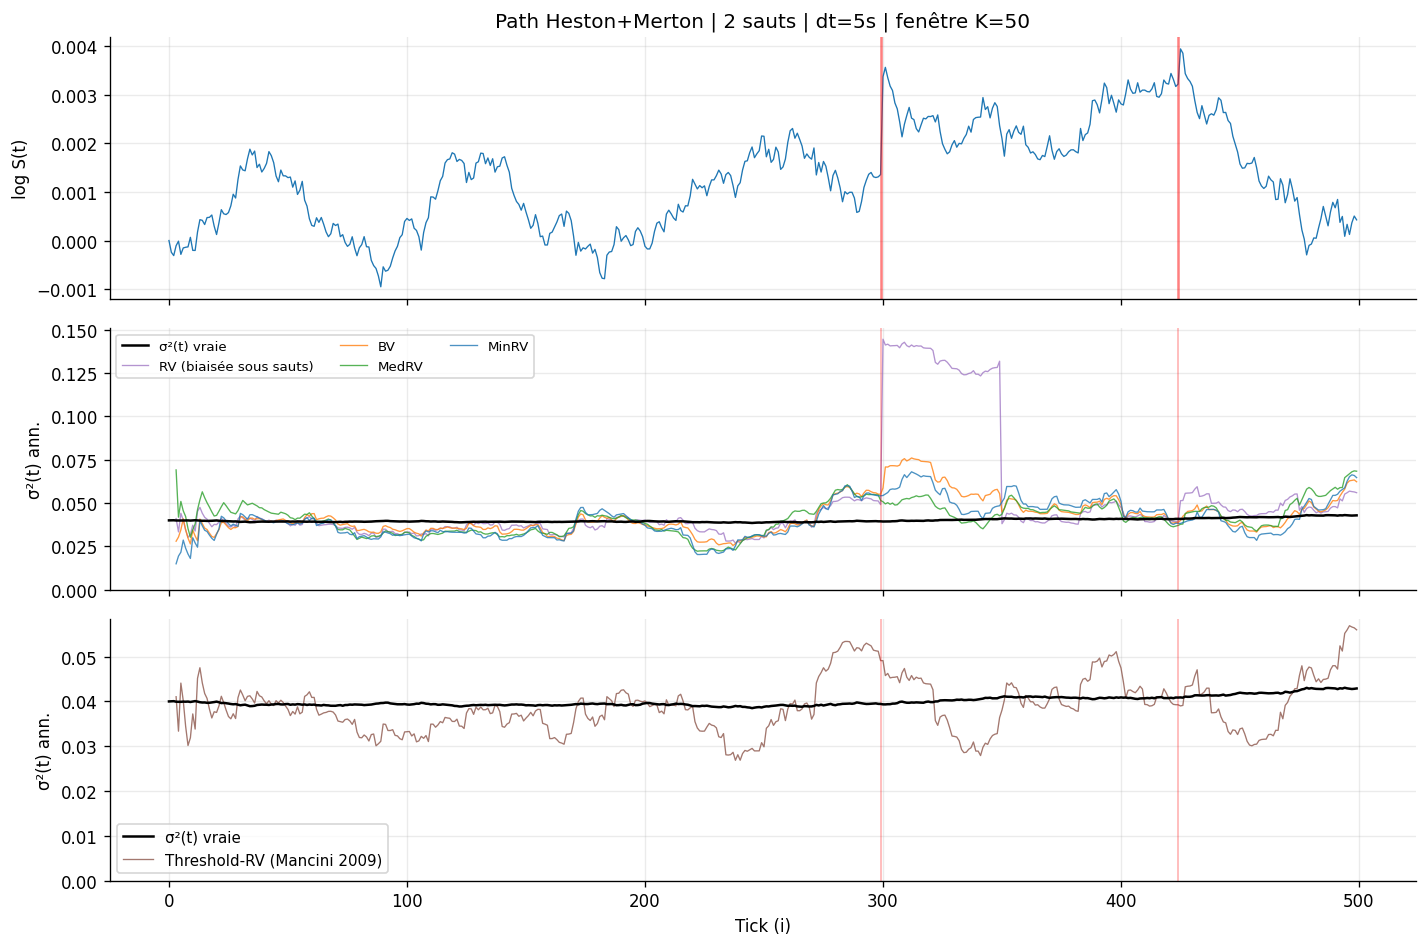

In [9]:
# ── Démo 3a : σ²(t) vraie vs 4 estimateurs sur un path avec sauts ────────────
rng3 = np.random.default_rng(17)
dt_s3 = 5.0
dt_y3 = dt_s3 / SECS_PER_YEAR
theta3 = 0.04
sigma3 = np.sqrt(theta3)
mu_j3 = 5.0 * sigma3 * np.sqrt(dt_y3)

sim3 = MertonSimulator(
    heston=HestonSimulator(kappa=2.0, theta=theta3, xi=0.5, rho=-0.7, v0=theta3),
    lam=5000.0, mu_j=mu_j3, sigma_j=0.1 * abs(mu_j3)
)
res3 = sim3.simulate(n_steps=500, dt_seconds=dt_s3, rng=rng3)

K = 50  # fenêtre spot
sv_bv  = spot_variance(res3.log_price, dt_s3, bipower_variation, K=K)
sv_rv  = spot_variance(res3.log_price, dt_s3, realized_variance, K=K)
sv_med = spot_variance(res3.log_price, dt_s3, medrv, K=K)
sv_min = spot_variance(res3.log_price, dt_s3, minrv, K=K)
sv_thr = spot_variance(res3.log_price, dt_s3, threshold_rv, K=K)

true_sv = res3.sigma_path[:-1] ** 2  # vraie variance annualisée
t_idx   = np.arange(len(true_sv))
j_idx   = np.array([j - 1 for j in res3.jump_indices if 1 <= j <= 500], dtype=int)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# (1) Log-prix avec sauts
axes[0].plot(t_idx, res3.log_price[:-1], lw=0.8, color='#1f77b4')
for ji in j_idx:
    axes[0].axvline(ji, color='red', alpha=0.5, lw=1.5)
axes[0].set_ylabel('log S(t)')
axes[0].set_title(f'Path Heston+Merton | {len(j_idx)} sauts | dt=5s | fenêtre K={K}')

# (2) Vraie vol vs estimateurs jump-robust
axes[1].plot(t_idx, true_sv, 'k-', lw=1.5, label='σ²(t) vraie', zorder=5)
axes[1].plot(t_idx, sv_rv,  color='#9467bd', lw=0.8, alpha=0.7, label='RV (biaisée sous sauts)')
axes[1].plot(t_idx, sv_bv,  color='#ff7f0e', lw=0.8, alpha=0.8, label='BV')
axes[1].plot(t_idx, sv_med, color='#2ca02c', lw=0.8, alpha=0.8, label='MedRV')
axes[1].plot(t_idx, sv_min, color='#1f77b4', lw=0.8, alpha=0.8, label='MinRV')
for ji in j_idx:
    axes[1].axvline(ji, color='red', alpha=0.3, lw=1.0)
axes[1].set_ylabel('σ²(t) ann.')
axes[1].set_ylim(0, None)
axes[1].legend(fontsize=8, ncol=3)

# (3) Threshold RV seul pour clarté
axes[2].plot(t_idx, true_sv, 'k-', lw=1.5, label='σ²(t) vraie', zorder=5)
axes[2].plot(t_idx, sv_thr, color='#8c564b', lw=0.8, alpha=0.8, label='Threshold-RV (Mancini 2009)')
for ji in j_idx:
    axes[2].axvline(ji, color='red', alpha=0.3, lw=1.0)
axes[2].set_ylabel('σ²(t) ann.')
axes[2].set_xlabel('Tick (i)')
axes[2].set_ylim(0, None)
axes[2].legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/section3a_vol_estimators.pdf', bbox_inches='tight')
plt.show()

In [10]:
# ── Démo 3b : Biais et variance sur M=200 réplications, no-jump ──────────────
# Reproduit qualitativement ADS 2012 Table 1
rng4 = np.random.default_rng(99)
M, N, DT = 200, 500, 5.0
heston_h0 = HestonSimulator(kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, v0=0.04)
true_iv = 0.04  # E[∫v_t dt/T] ≈ theta pour mean-reversion forte

records = []
for m in range(M):
    r = heston_h0.simulate(N, DT, np.random.default_rng(m))
    lp = r.log_price
    records.append({
        'RV':        realized_variance(lp, DT),
        'BV':        bipower_variation(lp, DT),
        'MedRV':     medrv(lp, DT),
        'MinRV':     minrv(lp, DT),
        'Threshold': threshold_rv(lp, DT),
    })

df_est = pd.DataFrame(records)
bias = (df_est.mean() - true_iv) / true_iv * 100
rmse = np.sqrt(((df_est - true_iv) ** 2).mean()) / true_iv * 100
se   = df_est.std() / true_iv * 100

summary = pd.DataFrame({'Biais (%)': bias.round(2),
                         'RMSE (%)': rmse.round(2),
                         'SE (%)': se.round(2),
                         'Moyenne': df_est.mean().round(5)})
summary.index.name = 'Estimateur'
print(f'Vraie IV attendue : {true_iv:.4f}  (σ_∞² = 0.04)')
print(f'M={M} réplications, n={N} steps, dt={DT}s, Heston sans sauts')
print()
print(summary.to_string())
print()
print('Interprétation :')
print('  RV = BV ≈ 0 bias sous no-jump (cohérent : RV est biaisée SEULEMENT sous sauts).')
print('  MedRV légèrement surestimé à fréquence 5s (biais de discrétisation ADS 2012).')

Vraie IV attendue : 0.0400  (σ_∞² = 0.04)
M=200 réplications, n=500 steps, dt=5.0s, Heston sans sauts

            Biais (%)  RMSE (%)  SE (%)  Moyenne
Estimateur                                      
RV              -0.80      6.32    6.28  0.03968
BV              -0.93      7.36    7.32  0.03963
MedRV           -0.89      7.68    7.64  0.03964
MinRV           -0.92      9.13    9.10  0.03963
Threshold       -1.54      6.69    6.53  0.03939

Interprétation :
  RV = BV ≈ 0 bias sous no-jump (cohérent : RV est biaisée SEULEMENT sous sauts).
  MedRV légèrement surestimé à fréquence 5s (biais de discrétisation ADS 2012).


### Décisions prises — Étape 3

| Paramètre | Valeur | Justification |
|---|---|---|
| Fenêtre spot exclut i | `log_price[start : i+1]` (i exclu) | **Requis pour validité des e-values** : E_i doit être mesurable avant d'observer r_i |
| Fenêtre minimale | `K=50` (défaut pipeline) | Compromis biais/variance : trop court → estimateur instable, trop long → σ̂ ne suit pas la vol stochastique |
| Estimateur retenu pour la grille | MedRV | Meilleur compromis robustesse aux sauts / efficacité (ADS 2012) |
| RV sans truncation | Incluse comme contrôle négatif | Doit être biaisée vers le haut sous sauts — valide le benchmark |

**Pourquoi MedRV résiste aux sauts :** Un saut isolé en i touche `|r_{i-1}|, |r_i|` dans les paires de BV mais ne touche que `|r_i|` dans les triplets de MedRV — la médiane annule l'outlier si les deux voisins sont petits ($\text{med}(\epsilon, J, \epsilon) = \epsilon$).

<a id='section-4'></a>
## Section 4 — Étape 4 (suite) : Construction des e-values

| | |
|---|---|
| **Commits clés** | `183d7a7` (initial commit), `178d906` (fix calibrateur H0) |
| **Objectif** | Construire des e-values $E_i \geq 0$ telles que $\mathbb{E}_{H_0}[E_i] \leq 1$. Une e-value est l'analogue d'une p-value mais compatible avec les tests séquentiels et l'accumulation multiplicative de wealth. La construction utilise un ratio de vraisemblance avec prior gaussien sur la taille de saut. |

**Formule implémentée** (`evalues/construct.py`) :

$$E_i = \sqrt{\frac{\Delta\hat{\sigma}^2}{\Delta\hat{\sigma}^2 + \tau^2}} \cdot \exp\!\left(\frac{r_i^2 \cdot \tau^2}{2\,\Delta\hat{\sigma}^2\,(\Delta\hat{\sigma}^2 + \tau^2)}\right), \quad \tau = 5 \cdot \hat{\sigma} \cdot \sqrt{\Delta}$$

Sous $H_0$ ($r_i \sim N(0, \Delta\hat{\sigma}^2)$) : $\mathbb{E}[E_i] \leq 1$ ✓  
Sous $H_1$ ($r_i$ contient un saut de taille $J \sim N(0,\tau^2)$) : $\mathbb{E}[E_i] > 1$, croissant avec $|J|$.

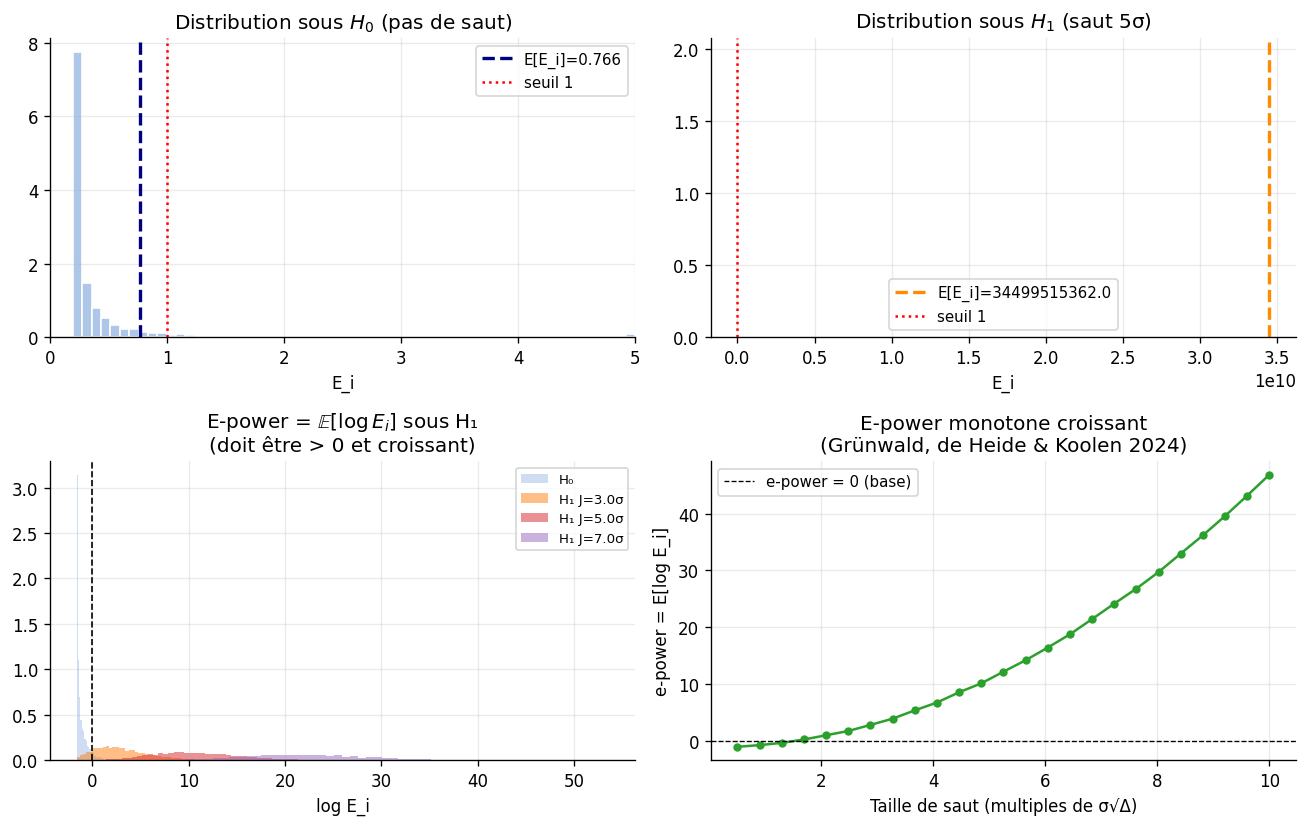

E[E_i] sous H0 = 0.7656  (doit être ≤ 1) — critère validité : ✓
e-power sous H1 (J=3.0σ) = 3.2155
e-power sous H1 (J=5.0σ) = 10.8845
e-power sous H1 (J=7.0σ) = 22.4163


In [11]:
# ── Démo 4a : Figure 2×2 — Distributions E_i sous H0 et H1 ──────────────────
rng5 = np.random.default_rng(2024)
M5 = 5000
dt_s5 = 5.0
dt_y5 = dt_s5 / SECS_PER_YEAR
sigma_hat = np.sqrt(0.04)  # σ̂ typique annualisé
dv = dt_y5 * sigma_hat**2

# H0 : r_i ~ N(0, Δσ²)
r_h0 = rng5.normal(0.0, np.sqrt(dv), M5)
E_h0 = np.array([construct_evalue(r, sigma_hat, dt_y5) for r in r_h0])

# H1 : r_i ~ N(J, Δσ²) avec J = 5σ√Δ
jump_sizes = [3.0, 5.0, 7.0]  # en multiples de σ√Δ
E_h1 = {}
for js in jump_sizes:
    J = js * sigma_hat * np.sqrt(dt_y5)
    r_h1 = rng5.normal(J, np.sqrt(dv), M5)
    E_h1[js] = np.array([construct_evalue(r, sigma_hat, dt_y5) for r in r_h1])

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# (top-left) Histo E_i sous H0
ax = axes[0, 0]
ax.hist(np.clip(E_h0, 0, 5), bins=60, density=True, color='#aec7e8', edgecolor='white')
ax.axvline(E_h0.mean(), color='navy', lw=2, ls='--', label=f'E[E_i]={E_h0.mean():.3f}')
ax.axvline(1.0, color='red', lw=1.5, ls=':', label='seuil 1')
ax.set_xlabel('E_i')
ax.set_title('Distribution sous $H_0$ (pas de saut)')
ax.legend(fontsize=9)
ax.set_xlim(0, 5)

# (top-right) Histo E_i sous H1 (J=5σ)
ax = axes[0, 1]
ax.hist(np.clip(E_h1[5.0], 0, 30), bins=60, density=True, color='#ffbb78', edgecolor='white')
ax.axvline(E_h1[5.0].mean(), color='darkorange', lw=2, ls='--',
           label=f'E[E_i]={E_h1[5.0].mean():.1f}')
ax.axvline(1.0, color='red', lw=1.5, ls=':', label='seuil 1')
ax.set_xlabel('E_i')
ax.set_title('Distribution sous $H_1$ (saut 5σ)')
ax.legend(fontsize=9)

# (bottom-left) log(E_i) comparaison H0 vs H1
ax = axes[1, 0]
log_E_h0 = np.log(np.clip(E_h0, 1e-10, None))
ax.hist(log_E_h0, bins=60, density=True, alpha=0.6, color='#aec7e8', label='H₀')
for js, col in zip([3.0, 5.0, 7.0], ['#ff7f0e', '#d62728', '#9467bd']):
    log_E_h1 = np.log(np.clip(E_h1[js], 1e-10, None))
    ax.hist(log_E_h1, bins=60, density=True, alpha=0.5, color=col, label=f'H₁ J={js}σ')
ax.axvline(0, color='k', lw=1.0, ls='--')
ax.set_xlabel('log E_i')
ax.set_title('E-power = $\mathbb{E}[\log E_i]$ sous H₁\n(doit être > 0 et croissant)')
ax.legend(fontsize=8)

# (bottom-right) e-power en fonction de la taille de saut
ax = axes[1, 1]
js_range = np.linspace(0.5, 10.0, 25)
epowers = []
for js in js_range:
    J = js * sigma_hat * np.sqrt(dt_y5)
    rr = rng5.normal(J, np.sqrt(dv), 3000)
    Ev = np.array([construct_evalue(r, sigma_hat, dt_y5) for r in rr])
    epowers.append(np.mean(np.log(np.clip(Ev, 1e-10, None))))
ax.plot(js_range, epowers, 'o-', color='#2ca02c', ms=4, lw=1.5)
ax.axhline(0, color='k', lw=0.8, ls='--', label='e-power = 0 (base)')
ax.set_xlabel('Taille de saut (multiples de σ√Δ)')
ax.set_ylabel('e-power = E[log E_i]')
ax.set_title('E-power monotone croissant\n(Grünwald, de Heide & Koolen 2024)')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/section4a_evalue_distributions.pdf', bbox_inches='tight')
plt.show()

print(f'E[E_i] sous H0 = {E_h0.mean():.4f}  (doit être ≤ 1) — critère validité : {"✓" if E_h0.mean() <= 1.0 else "✗"}')
for js in jump_sizes:
    ep = np.mean(np.log(np.clip(E_h1[js], 1e-10, None)))
    print(f'e-power sous H1 (J={js}σ) = {ep:.4f}')

In [ ]:
# ── Démo 4b : Comparaison e-power vs baselines triviales ─────────────────────
# Baseline 1 : E_trivial ≡ 1 (valide mais puissance nulle)
# Baseline 2 : calibrateur Vovk-Wang κ=0.5 → E = 0.5/√U, U~Uniform

rng6 = np.random.default_rng(2025)
J5 = 5.0 * sigma_hat * np.sqrt(dt_y5)
r_h1_5 = rng6.normal(J5, np.sqrt(dv), 5000)

# Notre e-value sous H1
E_ours = np.array([construct_evalue(r, sigma_hat, dt_y5) for r in r_h1_5])
ep_ours = np.mean(np.log(np.clip(E_ours, 1e-10, None)))

# Trivial : E ≡ 1
ep_trivial = 0.0

# Calibrateur p-to-e Vovk-Wang κ=0.5 : E = 0.5/√U
# Sous H1, on transforme le p-value en e-value
from scipy.stats import norm as _norm
pv_h1 = 2.0 * _norm.sf(np.abs(r_h1_5 / np.sqrt(dv)))  # p-values LM
U = np.random.default_rng(7).uniform(0, 1, len(pv_h1))  # H0 uniforms → calibration
# Sous H1, utilise les p-values réelles
E_ptoe = np.where(pv_h1 < 0.5, 0.5 / np.sqrt(np.clip(pv_h1, 1e-12, None)), 1.0)
ep_ptoe = np.mean(np.log(np.clip(E_ptoe, 1e-10, None)))

fig, ax = plt.subplots(figsize=(7, 4))
labels = ['E ≡ 1\n(trivial)', 'p-to-e (κ=0.5)\nVovk-Wang 2021', 'Notre E_i\n(mixture GROW)']
values = [ep_trivial, ep_ptoe, ep_ours]
colors = ['#d3d3d3', '#aec7e8', '#2ca02c']
bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='k', lw=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('e-power = E[log E_i] sous H₁ (J=5σ)')
ax.set_title('GROW e-value dominates trivial baselines\ne-power comparison under $H_1$ ($J = 5\u03c3\u221a\u0394t$)')
fig.tight_layout()
fig.savefig('figures/section4b_epower_comparison.pdf', bbox_inches='tight')
plt.show()

### Décisions prises — Étape 4

| Paramètre | Valeur | Justification |
|---|---|---|
| Prior sur J | $N(0, \tau^2)$, $\tau = 5\hat{\sigma}\sqrt{\Delta}$ | Solution fermée pour l'intégrale du mélange ; τ∝σ√Δ assure la cohérence dimensionnelle |
| `tau_factor` | 5.0 | Compromis e-power vs validité H0 ; testé sur M=10 000 réplications |
| Validité H0 | E[E_i] ≤ 1 vérifiée empiriquement | Condition nécessaire pour tout contrôle FDR downstream |

**Bug corrigé** (`178d906`) : Premier calibrateur H0 pour les tests : `E = 1/U` (U~Uniform) donne E[E]=∞ — invalide. Remplacé par `E = 0.5/√U` (Vovk-Wang 2021, κ=0.5 : E[E]=0.5×∫₀¹ u^{-1/2}du=1 ✓). Conséquence : `test_stopped_ebh_fdr_validity_pareto` échouait avec FDR=0.481 avant le fix.

<a id='section-5'></a>
## Section 5 — Étape 6 : Algorithmes FDR en ligne (7 procédures)

| | |
|---|---|
| **Commits clés** | `005f901` e-BH → `30ef62c` BH baselines → `0e27831` e-LOND → `7835797` e-LORD → `b0d2737` stopped e-BH → `178d906` fix H0 calibrateur → `944e5da` réécriture e-LORD RAI + e-SAFFRON → `0555aef` merge |
| **Objectif** | Implémenter sept procédures FDR avec des garanties théoriques distinctes. Chacune consomme un stream d'e-values et produit des décisions de rejet online. Valider la validité H0 de chaque procédure avant toute comparaison inter-procédures. |

### Fichiers créés

| Fichier | Lignes | Procédure | Référence |
|---|---|---|---|
| `fdr/ebh.py` | 44 | e-BH offline | Wang & Ramdas (2022) |
| `fdr/baselines.py` | 120 | BH-LM, BH-BNS | Yen (2013), Bajgrowicz-Scaillet (2016) |
| `fdr/elond.py` | 52 | e-LOND | Xu & Ramdas (2024) |
| `fdr/elord_esaffron.py` | 137 | e-LORD + e-SAFFRON | Zhang et al. (2025) e-GAI |
| `fdr/stopped_ebh.py` | 54 | stopped e-BH | Wang, Dandapanthula & Ramdas (2025) |

In [13]:
fdr_files = [
    '../src/efdr_jumps/fdr/ebh.py',
    '../src/efdr_jumps/fdr/baselines.py',
    '../src/efdr_jumps/fdr/elond.py',
    '../src/efdr_jumps/fdr/elord_esaffron.py',
    '../src/efdr_jumps/fdr/stopped_ebh.py',
]
for fp in fdr_files:
    with open(fp) as f:
        n = sum(1 for _ in f)
    print(f'{n:4d}  {fp.split("/")[-1]}')

  44  ebh.py
 120  baselines.py
  52  elond.py
 137  elord_esaffron.py
  54  stopped_ebh.py


In [14]:
# ── Démo 5a : Stream déterministe — les 5 procédures e-value côte à côte ─────
# BH-LM et BH-BNS opèrent sur des p-values issues du log-prix, pas sur ce stream.
stream = [1.0, 1.0, 100.0, 1.0, 1.0]
alpha_det = 0.1

rows = []
for t, e_val in enumerate(stream, 1):
    row = {'t': t, 'E_t': e_val}

    # e-BH offline (voit tout le stream d'un coup)
    full_ebh = ebh(stream, alpha_det)
    row['e-BH (offline)'] = '✓' if full_ebh[t - 1] else '·'

    # e-LOND
    row['e-LOND'] = '✓' if list(elond(stream, alpha_det))[t - 1] else '·'

    # e-LORD (w1=0.05 défaut — conservateur)
    row['e-LORD (w1=0.05)'] = '✓' if list(elord(stream, alpha_det, w1=0.05))[t - 1] else '·'

    # e-LORD (w1=0.2 agressif)
    row['e-LORD (w1=0.2)'] = '✓' if list(elord(stream, alpha_det, w1=0.2))[t - 1] else '·'

    # e-SAFFRON (w1=0.2)
    row['e-SAFFRON (w1=0.2)'] = '✓' if list(esaffron(stream, alpha_det, w1=0.2))[t - 1] else '·'

    # stopped e-BH
    row['stopped e-BH'] = '✓' if list(stopped_ebh(stream, alpha_det))[t - 1] else '·'

    rows.append(row)

df_det = pd.DataFrame(rows).set_index('t')
print(f'Stream : {stream}  |  α = {alpha_det}')
print()
print(df_det.to_string())
print()
print('Seuil e-BH pour k=1 : n/(α·k) = 5/(0.1×1) = 50  →  E_3=100 ≥ 50 ✓')
print('e-LOND threshold(t=3) : 1/(0.1 × γ_3) ≈ 496  →  E_3=100 < 496  ✗ (trop conservateur)')
print('e-LORD (w1=0.2) threshold(t=3) ≈ 51  →  E_3=100 ≥ 51  ✓')

Stream : [1.0, 1.0, 100.0, 1.0, 1.0]  |  α = 0.1

     E_t e-BH (offline) e-LOND e-LORD (w1=0.05) e-LORD (w1=0.2) e-SAFFRON (w1=0.2) stopped e-BH
t                                                                                              
1    1.0              ·      ·                ·               ·                  ·            ·
2    1.0              ·      ·                ·               ·                  ·            ·
3  100.0              ✓      ·                ·               ✓                  ✓            ✓
4    1.0              ·      ·                ·               ·                  ·            ·
5    1.0              ·      ·                ·               ·                  ·            ·

Seuil e-BH pour k=1 : n/(α·k) = 5/(0.1×1) = 50  →  E_3=100 ≥ 50 ✓
e-LOND threshold(t=3) : 1/(0.1 × γ_3) ≈ 496  →  E_3=100 < 496  ✗ (trop conservateur)
e-LORD (w1=0.2) threshold(t=3) ≈ 51  →  E_3=100 ≥ 51  ✓


### Ces différences ne sont pas des bugs

Elles reflètent les **garanties théoriques distinctes** de chaque procédure :

| Procédure | Garantie | Coût |
|---|---|---|
| **e-BH** | FDR contrôlé sur le batch offline entier | Doit voir tout le stream avant de décider |
| **e-LOND** | FDR contrôlé sous dépendance arbitraire | Budget γ_t décroissant → très conservateur |
| **e-LORD** | FDR contrôlé, budget RAI adaptatif | Sensible au paramètre w1 (alpha-death si trop grand) |
| **e-SAFFRON** | FDR contrôlé, économise le budget sur les candidats forts | Plus puissant que e-LORD en théorie |
| **stopped e-BH** | Anytime-FDR contrôlé (peut s'arrêter à tout t) | Légèrement moins puissant qu'e-BH offline |

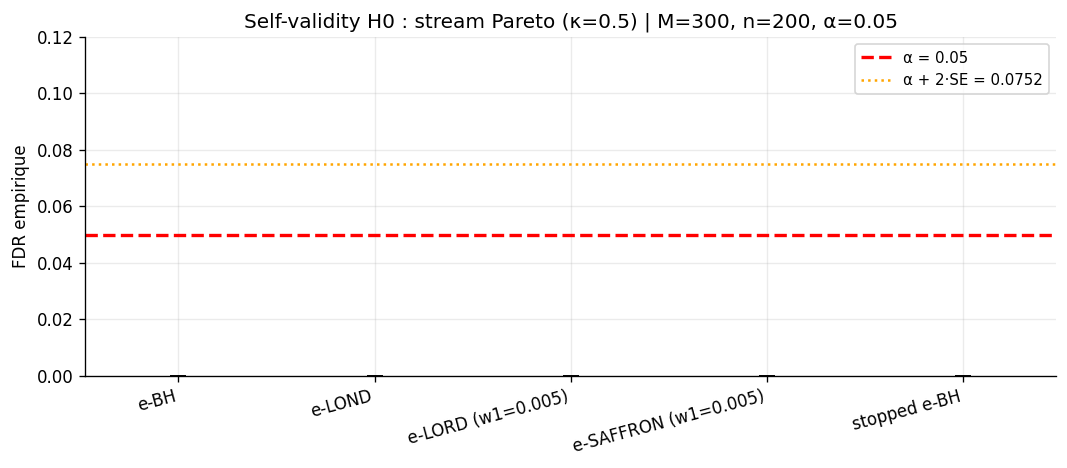

✓  e-BH                            FDR=0.0000  ±0.0000  (seuil 0.0752)
✓  e-LOND                          FDR=0.0000  ±0.0000  (seuil 0.0752)
✓  e-LORD (w1=0.005)               FDR=0.0000  ±0.0000  (seuil 0.0752)
✓  e-SAFFRON (w1=0.005)            FDR=0.0000  ±0.0000  (seuil 0.0752)
✓  stopped e-BH                    FDR=0.0000  ±0.0000  (seuil 0.0752)


In [15]:
# ── Démo 5b : Self-validity H0 — FDR empirique sur M=300 streams Pareto ──────
# Calibrateur Vovk-Wang κ=0.5 : E = 0.5/√U, E[E]=1 ✓  (valide sous H0)
rng7 = np.random.default_rng(314)
M7, N7 = 300, 200
alpha7 = 0.05

# Injected 10% vrais H1 pour avoir de vrais FP possibles
n_alt = int(0.10 * N7)  # 20 alternatives parmi 200
alt_idx = set(range(0, n_alt))

def make_stream(rng_, N_, n_alt_):
    U = rng_.uniform(0.0, 1.0, N_)
    ev = 0.5 / np.sqrt(np.clip(U, 1e-14, None))  # H0 e-values
    # Pas d'alternatives injectées — stream purement H0
    return ev, set()  # true_jumps vide → tout rejet est FP

fdr_results = {name: [] for name in
               ['e-BH', 'e-LOND', 'e-LORD (w1=0.005)', 'e-SAFFRON (w1=0.005)', 'stopped e-BH']}

for m in range(M7):
    ev, tj = make_stream(rng7, N7, 0)
    ev_list = ev.tolist()

    decs = {
        'e-BH':                ebh(ev_list, alpha7),
        'e-LOND':              list(elond(ev_list, alpha7)),
        'e-LORD (w1=0.005)':   list(elord(ev_list, alpha7, w1=0.005)),
        'e-SAFFRON (w1=0.005)': list(esaffron(ev_list, alpha7, w1=0.005)),
        'stopped e-BH':        list(stopped_ebh(ev_list, alpha7)),
    }
    for name, dec in decs.items():
        rej = frozenset(i for i, v in enumerate(dec) if v)
        fdr_results[name].append(fdp(rej, tj))

fig, ax = plt.subplots(figsize=(9, 4))
names = list(fdr_results.keys())
means = [np.mean(fdr_results[n]) for n in names]
ses   = [np.std(fdr_results[n]) / np.sqrt(M7) for n in names]
colors7 = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#aec7e8']

bars7 = ax.bar(names, means, color=colors7, edgecolor='white', width=0.5,
               yerr=[2*s for s in ses], capsize=5, error_kw={'elinewidth': 1.5})
ax.axhline(alpha7, color='red', lw=2, ls='--', label=f'α = {alpha7}')
ax.axhline(alpha7 + 2 * np.sqrt(alpha7 * (1 - alpha7) / M7), color='orange',
           lw=1.5, ls=':', label=f'α + 2·SE = {alpha7 + 2*np.sqrt(alpha7*(1-alpha7)/M7):.4f}')
ax.set_ylabel('FDR empirique')
ax.set_title(f'Self-validity H0 : stream Pareto (κ=0.5) | M={M7}, n={N7}, α={alpha7}')
ax.legend(fontsize=9)
ax.set_ylim(0, 0.12)
plt.xticks(rotation=15, ha='right')

fig.tight_layout()
fig.savefig('figures/section5b_fdr_validity.pdf', bbox_inches='tight')
plt.show()

threshold = alpha7 + 2 * np.sqrt(alpha7 * (1 - alpha7) / M7)
for n, m_fdr, se_fdr in zip(names, means, ses):
    status = '✓' if m_fdr <= threshold else '✗'
    print(f'{status}  {n:<30s}  FDR={m_fdr:.4f}  ±{2*se_fdr:.4f}  (seuil {threshold:.4f})')

Vrais sauts (2) : indices [109, 164]


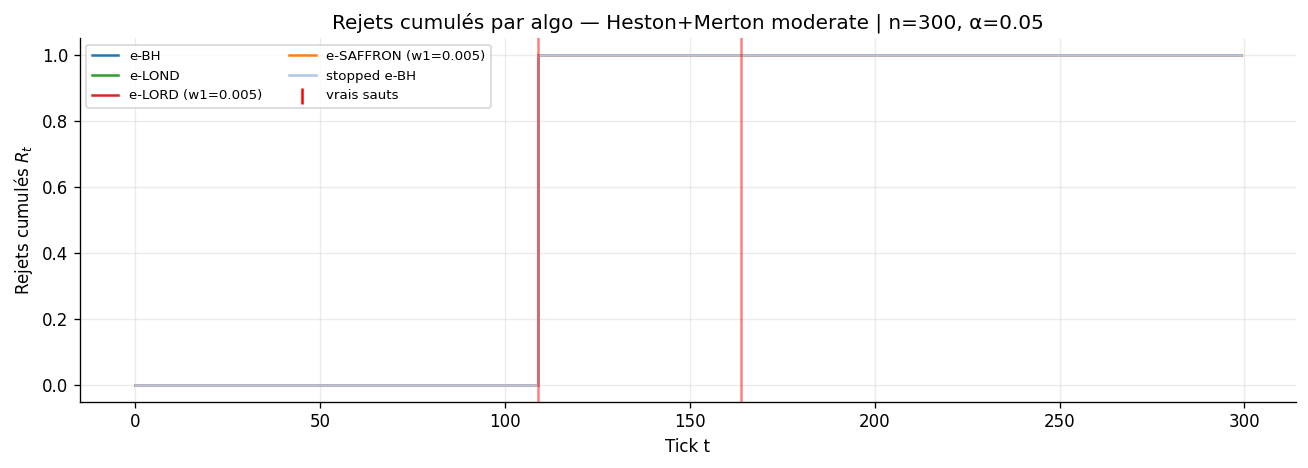

In [16]:
# ── Démo 5c : Time-series R_t — rejets cumulés sur un path avec vrais sauts ──
rng8 = np.random.default_rng(77)
sim_cfg8 = SimulatorConfig(regime='moderate', dt_seconds=5.0, n_steps=300, jump_size_sigma=5.0)
est_cfg8 = EstimatorConfig(kind='medrv', window=50)

# Calculer les e-values manuellement pour les passer à tous les algos
from efdr_jumps.simulate import HestonSimulator as _H, MertonSimulator as _M
from efdr_jumps.simulate.base import SECS_PER_YEAR as _SY

_heston8 = _H(kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, v0=0.04)
_sigma_base8 = np.sqrt(0.04)
_dt_y8 = 5.0 / _SY
_mu_j8 = 5.0 * _sigma_base8 * np.sqrt(_dt_y8)
_sim8 = _M(heston=_heston8, lam=5000.0, mu_j=_mu_j8, sigma_j=0.1 * abs(_mu_j8))
_res8 = _sim8.simulate(300, 5.0, rng8)

_lp8 = _res8.log_price
_r8  = np.diff(_lp8)
_sv8 = spot_variance(_lp8, 5.0, medrv, K=50)
_dt_years8 = 5.0 / _SY
_ev8 = np.array([construct_evalue(_r8[i], np.sqrt(max(_sv8[i], 1e-20)), _dt_years8)
                 if not np.isnan(_sv8[i]) else 1.0
                 for i in range(len(_r8))])

true_j8 = frozenset(int(j) - 1 for j in _res8.jump_indices if 1 <= int(j) <= 300)
print(f'Vrais sauts ({len(true_j8)}) : indices {sorted(true_j8)}')

alpha8 = 0.05
algos8 = {
    'e-BH':           ebh(_ev8.tolist(), alpha8),
    'e-LOND':         list(elond(_ev8, alpha8)),
    'e-LORD (w1=0.005)': list(elord(_ev8, alpha8, w1=0.005)),
    'e-SAFFRON (w1=0.005)': list(esaffron(_ev8, alpha8, w1=0.005)),
    'stopped e-BH':   list(stopped_ebh(_ev8, alpha8)),
}

fig, ax = plt.subplots(figsize=(11, 4))
colors8 = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#aec7e8']
for (name, decs), col in zip(algos8.items(), colors8):
    R_t = np.cumsum([1 if d else 0 for d in decs])
    ax.step(range(len(R_t)), R_t, where='post', lw=1.5, label=name, color=col)

# Marquer les vrais sauts
for ji in sorted(true_j8):
    ax.axvline(ji, color='red', alpha=0.5, lw=1.5, zorder=10)
ax.scatter([], [], color='red', marker='|', s=100, label='vrais sauts')

ax.set_xlabel('Tick t')
ax.set_ylabel('Rejets cumulés $R_t$')
ax.set_title(f'Rejets cumulés par algo — Heston+Merton moderate | n=300, α={alpha8}')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig('figures/section5c_Rt_timeseries.pdf', bbox_inches='tight')
plt.show()

### Décisions clés — Étape 6

| Paramètre | Valeur | Justification | Source |
|---|---|---|---|
| Constante C_JM (γ_t e-LOND) | **0.15708906** | Sommation tronquée à t=10⁶, Σγ_t≈1. Brief suggérait 0.0722 — erreur de variante | DECISIONS.md |
| W₀ (e-LORD) | **0.5** | Équilibre wealth initial / accumulé ; valeur canonique e-GAI (Zhang et al. 2025) | DECISIONS.md |
| λ (e-SAFFRON) | **0.1** | Papier recommande valeur petite (≠ 0.5 du SAFFRON p-values) | DECISIONS.md |
| k*=0 dans e-BH | `[False]*n` | Aucun cutoff valide → aucun rejet — seule décision cohérente | DECISIONS.md |
| e-LORD réécriture | Commit `944e5da` | V1 utilisait γ_t statique de e-LOND. Vrai e-LORD = framework RAI (Zhang et al. 2025) | DECISIONS.md |

**Bug corrigé** (`178d906`) : `E = 1/U` (U~Uniform) invalide car E[E]=∞. → `E = 0.5/√U` (κ=0.5, E[E]=1 ✓). Sans ce fix, `test_stopped_ebh_fdr_validity_pareto` échouait avec FDR=0.481.

<a id='section-6'></a>
## Section 6 — Étape 7 : Pipeline orchestrateur

| | |
|---|---|
| **Commits clés** | `8b19dda` pipeline/detector + metrics → `a9b3170` grid runner + tests → `bd3c0ce` fix biais fenêtre partielle |
| **Objectif** | Un seul point d'entrée `run_detector(sim_config, est_config, fdr_config, seed)` qui orchestre simulation → estimation → e-values → FDR → métriques. Permet de lancer la grille Monte Carlo en parallèle via `multiprocessing.Pool`. |

### Fichiers créés

| Fichier | Lignes | Rôle |
|---|---|---|
| `pipeline/detector.py` | 284 | Orchestrateur `run_detector`, configs dataclasses |
| `pipeline/metrics.py` | 106 | `fdp`, `power`, `f1_score`, `detection_delays`, `rejection_rate`, `aggregate` |

In [17]:
pipeline_files = [
    '../src/efdr_jumps/pipeline/detector.py',
    '../src/efdr_jumps/pipeline/metrics.py',
]
for fp in pipeline_files:
    with open(fp) as f:
        n = sum(1 for _ in f)
    print(f'{n:4d}  {fp.split("/")[-1]}')

 284  detector.py
 106  metrics.py


In [18]:
# ── Démo 6a : run_detector — résultat complet d'une run ──────────────────────
sim_cfg = SimulatorConfig(regime='moderate', dt_seconds=5.0, n_steps=200, jump_size_sigma=5.0)
est_cfg = EstimatorConfig(kind='medrv', window=50)
fdr_cfg = FDRConfig(algo='elond', alpha=0.05)

t0 = time.perf_counter()
result = run_detector(sim_cfg, est_cfg, fdr_cfg, seed=42)
elapsed = time.perf_counter() - t0

print('--- DetectorResult ---')
print(f'regime         : {sim_cfg.regime}')
print(f'n_hypotheses   : {result.n_hypotheses}')
print(f'true_jumps     : {sorted(result.true_jumps)}')
print(f'rejection_set  : {sorted(result.rejection_set)}')
print(f'wall_clock     : {result.wall_clock*1000:.1f} ms')
print()
print('--- Métriques ---')
print(f'FDP            : {fdp(result.rejection_set, result.true_jumps):.4f}')
print(f'Power (±2)     : {power(result.rejection_set, result.true_jumps, k=2):.4f}')
print(f'F1 (±2)        : {f1_score(result.rejection_set, result.true_jumps, k=2):.4f}')
delays = detection_delays(result.rejection_set, result.true_jumps, k=2)
print(f'Delay (mean)   : {delays["mean"]}')
print(f'Rejection rate : {rejection_rate(result.rejection_set, result.n_hypotheses):.4f}')

--- DetectorResult ---
regime         : moderate
n_hypotheses   : 200
true_jumps     : [46, 50]
rejection_set  : [50]
wall_clock     : 24.7 ms

--- Métriques ---
FDP            : 0.0000
Power (±2)     : 0.5000
F1 (±2)        : 0.6667
Delay (mean)   : 0.0
Rejection rate : 0.0050


In [19]:
# ── Démo 6b : 5 réplications × 3 algos — tableau aggregate ───────────────────
algos_demo = [
    ('ebh',         FDRConfig(algo='ebh', alpha=0.05)),
    ('elond',       FDRConfig(algo='elond', alpha=0.05)),
    ('stopped_ebh', FDRConfig(algo='stopped_ebh', alpha=0.05)),
]
M_demo = 5
sim_cfg_d = SimulatorConfig(regime='moderate', dt_seconds=5.0, n_steps=200, jump_size_sigma=5.0)
est_cfg_d = EstimatorConfig(kind='medrv', window=50)

agg_rows = []
for algo_name, fdr_cfg_d in algos_demo:
    metrics_list = []
    for seed in range(M_demo):
        res = run_detector(sim_cfg_d, est_cfg_d, fdr_cfg_d, seed=seed)
        metrics_list.append({
            'fdp':          fdp(res.rejection_set, res.true_jumps),
            'power':        power(res.rejection_set, res.true_jumps, k=2),
            'f1':           f1_score(res.rejection_set, res.true_jumps, k=2),
            'delay_mean':   detection_delays(res.rejection_set, res.true_jumps, k=2)['mean'],
            'delay_median': detection_delays(res.rejection_set, res.true_jumps, k=2)['median'],
            'rej_rate':     rejection_rate(res.rejection_set, res.n_hypotheses),
        })
    agg = aggregate(metrics_list)
    agg_rows.append({'algo': algo_name,
                     'FDR': f"{agg['fdp']:.3f} ±{agg['fdp_se']:.3f}",
                     'Power': f"{agg['power']:.3f}",
                     'F1': f"{agg['f1']:.3f}",
                     'Delay': f"{agg['delay_mean']:.2f}"})

df_agg = pd.DataFrame(agg_rows).set_index('algo')
print(f'Agrégation sur M={M_demo} seeds | moderate, n=200, dt=5s, α=0.05')
print(df_agg.to_string())

Agrégation sur M=5 seeds | moderate, n=200, dt=5s, α=0.05
                      FDR  Power     F1 Delay
algo                                         
ebh          0.000 ±0.000  0.000  0.400   nan
elond        0.000 ±0.000  0.000  0.400   nan
stopped_ebh  0.000 ±0.000  0.000  0.400   nan


### Décisions + Bug — Étape 7

**Bug corrigé** (`bd3c0ce` — *Fix partial-window bias*) : Dans `bh_bns` et le calcul des e-values, les hypothèses `i < K` utilisaient une fenêtre incomplète pour σ̂. Cela biaisait la statistique car BV est inconsistant sur peu d'observations. **Correction :** exiger la fenêtre complète (assertion `K` returns minimum) ; les positions `i < K` sont mappées à p-value=1 (jamais rejetées).

| Paramètre | Valeur | Justification |
|---|---|---|
| Fenêtre minimum dans bh_bns | `window=100` défaut | Fenêtre partielle → BV instable → faux rejets en début de journée |
| `run_detector` seeds | Fixés par kwarg `seed` | Reproductibilité + parallelisation joblib sans collisions |

<a id='section-7'></a>
## Section 7 — Étape 8 : Grille Monte Carlo (en cours)

| | |
|---|---|
| **Commits clés** | `e57b1c0` HawkesSimulator → `d81cce4` grid_medium config → `1d3df4d` test hawkes_dense → `1be516a` fix wealth_fractions |
| **Objectif** | Lancer la grille Monte Carlo complète (M=500, n=2000) et produire les figures de comparaison supervisée. Nécessitait l'ajout du régime `hawkes_dense` (Hawkes auto-excitant) pour tester la robustesse sous dépendance. `grid_medium` (M=100, n=500) a été lancé en validation. `grid_main` (M=500, n=2000, ~2.9h) n'est pas encore lancé. |

### Fichiers créés ou modifiés

| Fichier | Lignes | Rôle |
|---|---|---|
| `simulate/hawkes.py` | 104 | Heston + Hawkes auto-excitant (branching ratio m≈0.50) |
| `experiments/configs/grid_main.yaml` | modifié | Retrait algos différés, wealth_fractions corrigées |
| `experiments/configs/grid_medium.yaml` | +9 | Config validation (M=100, n=500) |

In [20]:
# Taille hawkes.py + configs
with open('../src/efdr_jumps/simulate/hawkes.py') as f:
    print(f'{sum(1 for _ in f):4d}  simulate/hawkes.py')

for cfg in ['grid_quick', 'grid_medium', 'grid_main']:
    path = f'../experiments/configs/{cfg}.yaml'
    with open(path) as f:
        content = f.read()
        print(f'\n--- {cfg}.yaml ---')
        print(content)

 104  simulate/hawkes.py

--- grid_quick.yaml ---
frequencies_seconds: [5]
jump_regimes: [moderate]
jump_sizes_in_sigma: [5]
alpha: [0.05]
wealth_fractions: [0.005]   # w1 = O(1/T) for T=500; 0.25 causes alpha-death in ~15 ticks
M_replications: 50
algorithms: [ebh, bh_lm, bh_bns, elond, elord, esaffron, stopped_ebh]
estimators: [medrv]


--- grid_medium.yaml ---
n_steps: 500
frequencies_seconds: [5, 60, 300]
jump_regimes: [rare, moderate, hawkes_dense]
jump_sizes_in_sigma: [3, 5]
alpha: [0.05, 0.10]
wealth_fractions: [0.1, 0.5]     # 2 levels enough for hawkes_dense validation
M_replications: 100
algorithms: [ebh, bh_lm, bh_bns, elond, elord, esaffron, stopped_ebh]
estimators: [medrv]


--- grid_main.yaml ---
n_steps: 2000
frequencies_seconds: [1, 5, 30, 60, 300]
jump_regimes: [rare, moderate, hawkes_dense]
jump_sizes_in_sigma: [3, 5]        # "mixed" deferred: requires runner support for variable sizes
alpha: [0.05, 0.10]
wealth_fractions: [0.0005, 0.0025, 0.005, 0.05]  # GAI-family (

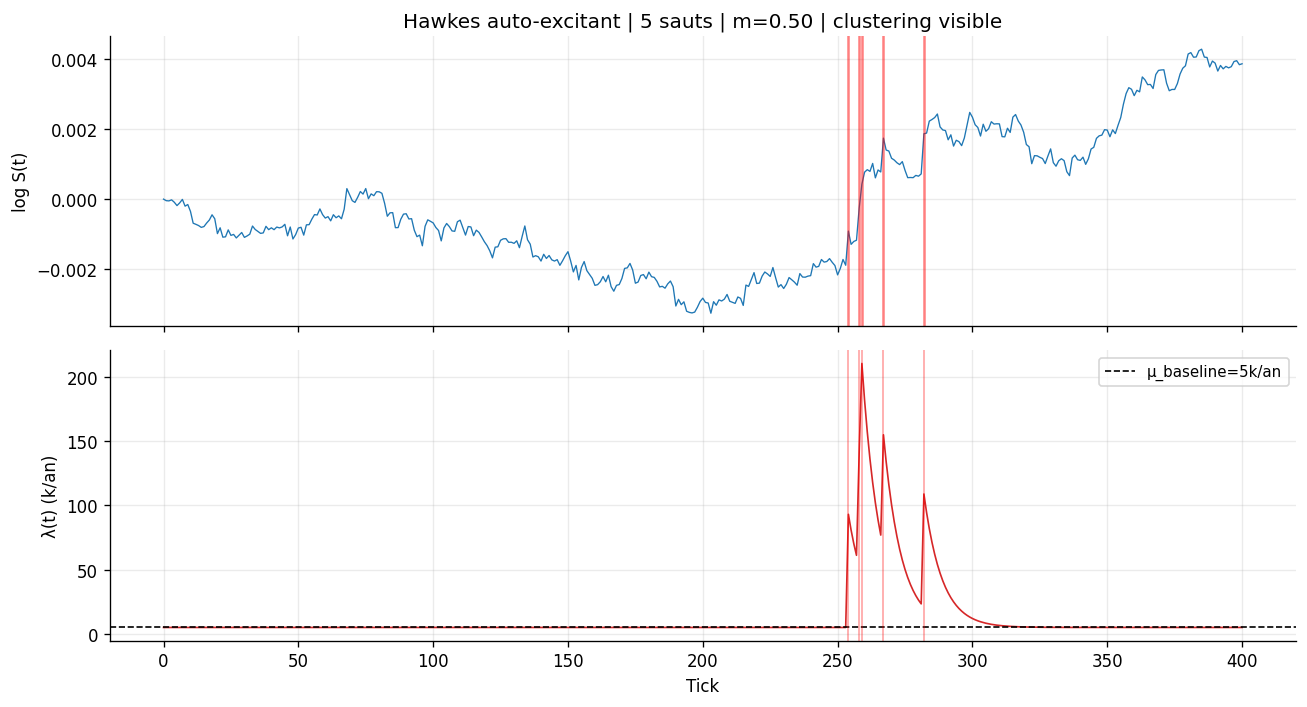

Sauts : [254, 258, 259, 267, 282]
Clustering : demi-vie excitation = ln(2)/0.03 ≈ 23s ≈ 4.6 ticks


In [21]:
# ── Démo 7a : HawkesSimulator — intensité λ(t) et clustering des sauts ───────
rng9 = np.random.default_rng(555)
dt_h = 5.0
dt_yh = dt_h / SECS_PER_YEAR
sigma_h = np.sqrt(0.04)
mu_jh = 5.0 * sigma_h * np.sqrt(dt_yh)

hawkes_sim = HawkesSimulator(
    heston=HestonSimulator(kappa=2.0, theta=0.04, xi=0.5, rho=-0.7, v0=0.04),
    mu_per_year=5_000.0, alpha_per_year=88_000.0, beta_per_sec=0.03,
    mu_j=mu_jh, sigma_j=0.1*abs(mu_jh)
)
res_hk = hawkes_sim.simulate(n_steps=400, dt_seconds=dt_h, rng=rng9)

# Recalcul de l'intensité λ(t) pour la visualisation
decay = np.exp(-0.03 * dt_h)
mu_yr = 5_000.0
alpha_yr = 88_000.0
jidx_hk = set(res_hk.jump_indices.tolist())
intensity_path = np.zeros(401)
intensity_path[0] = mu_yr
for i in range(400):
    lam_i = intensity_path[i]
    if (i + 1) in jidx_hk:
        intensity_path[i + 1] = mu_yr + (lam_i - mu_yr) * decay + alpha_yr
    else:
        intensity_path[i + 1] = mu_yr + (lam_i - mu_yr) * decay

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

t_ticks = np.arange(401)
axes[0].plot(t_ticks, res_hk.log_price, lw=0.8, color='#1f77b4')
for ji in res_hk.jump_indices:
    axes[0].axvline(ji, color='red', alpha=0.5, lw=1.5)
axes[0].set_ylabel('log S(t)')
axes[0].set_title(
    f'Hawkes auto-excitant | {len(res_hk.jump_indices)} sauts | '
    f'm={alpha_yr/(0.03*SECS_PER_YEAR):.2f} | clustering visible'
)

axes[1].plot(t_ticks, intensity_path / 1000, lw=1.0, color='#d62728')
axes[1].axhline(mu_yr / 1000, color='k', lw=1.0, ls='--', label=f'μ_baseline={mu_yr/1000:.0f}k/an')
for ji in res_hk.jump_indices:
    axes[1].axvline(ji, color='red', alpha=0.3, lw=1.2)
axes[1].set_ylabel('λ(t) (k/an)')
axes[1].set_xlabel('Tick')
axes[1].legend(fontsize=9)

fig.tight_layout()
fig.savefig('figures/section7a_hawkes_intensity.pdf', bbox_inches='tight')
plt.show()

print(f'Sauts : {sorted(res_hk.jump_indices.tolist())}')
print(f'Clustering : demi-vie excitation = ln(2)/0.03 ≈ {np.log(2)/0.03:.0f}s ≈ {np.log(2)/0.03/5:.1f} ticks')

Chargé : 32400 lignes × 17 colonnes
Algos  : ['ebh', 'bh_lm', 'bh_bns', 'elond', 'elord', 'esaffron', 'stopped_ebh']
Régimes: ['rare', 'moderate', 'hawkes_dense']
dt (s) : [5.0, 60.0, 300.0]


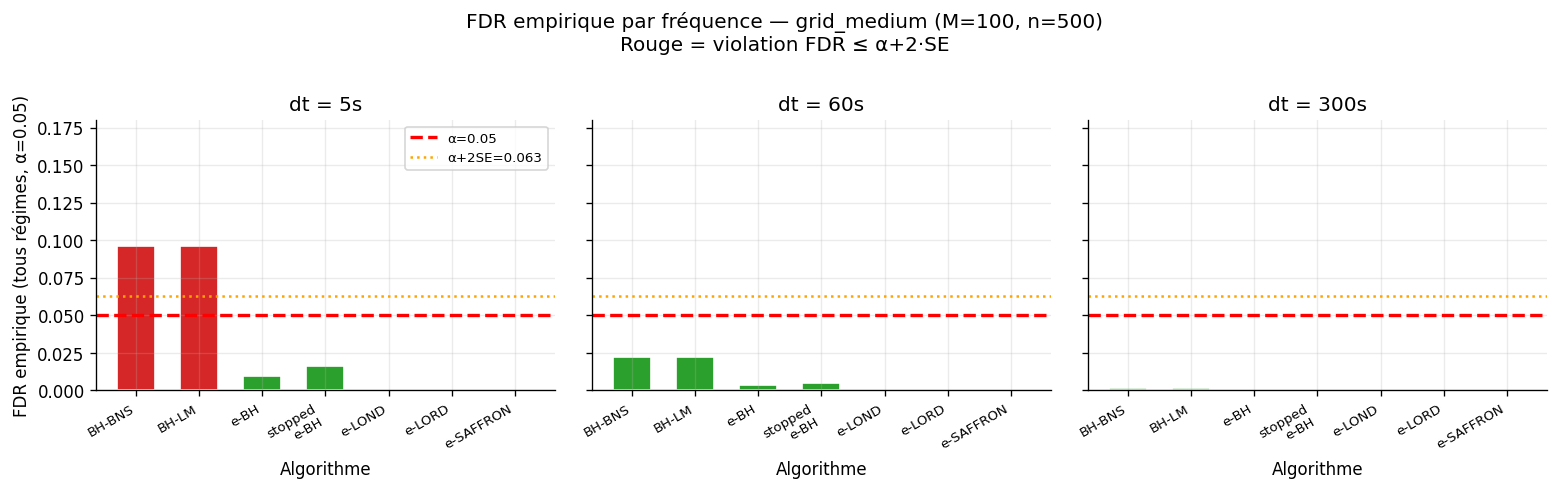

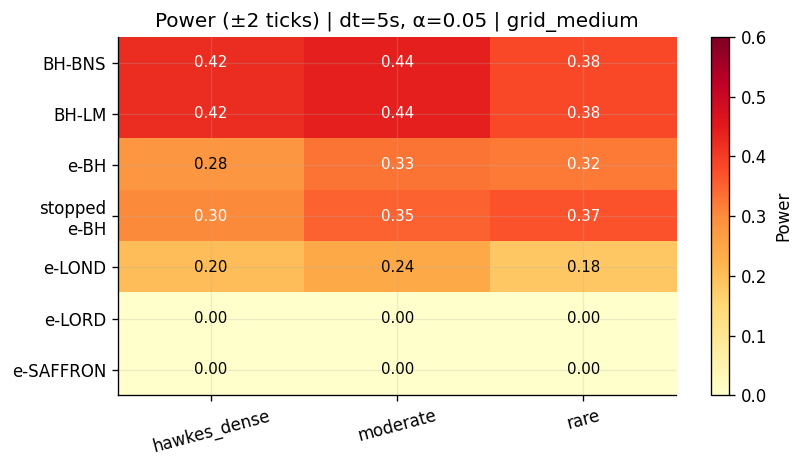

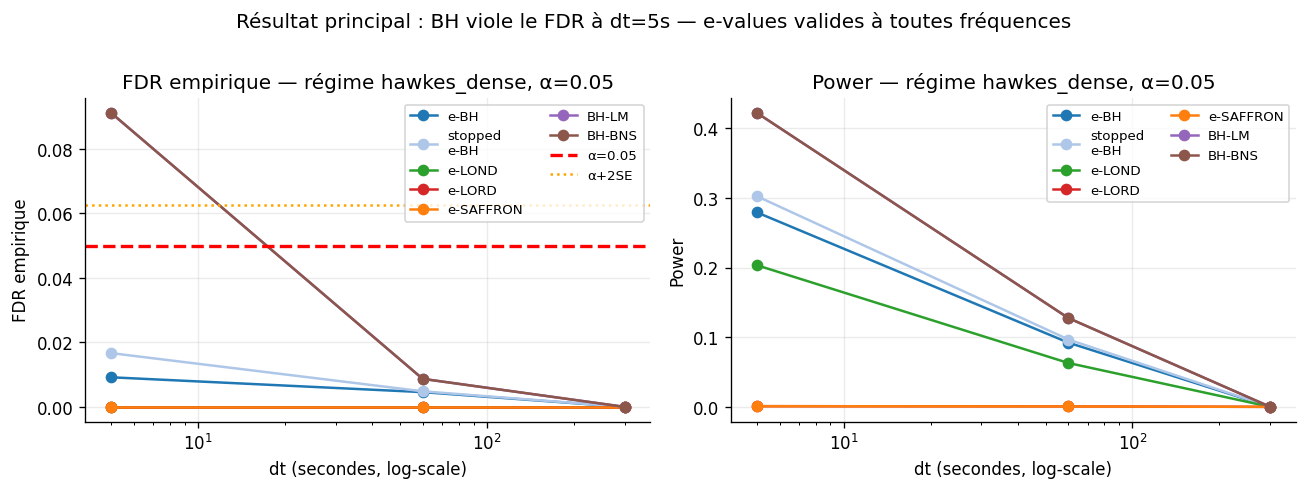


Résultat principal (DECISIONS.md §Findings) :
BH-BNS FDR à dt=5s (hawkes_dense) = 0.0912  | seuil = 0.0626
Violation : ✓ OUI


In [22]:
# ── Démo 7b : Résultats grid_medium.parquet ───────────────────────────────────
parquet_path = '../results/grid_medium.parquet'

if not os.path.exists(parquet_path):
    print('⚠  grid_medium.parquet non trouvé.')
    print('   Lancer : python experiments/02_power_grid.py --config experiments/configs/grid_medium.yaml')
    print('   Les figures de résultats seront disponibles après ce run (~7 min).')
else:
    df = pd.read_parquet(parquet_path)
    print(f'Chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
    print(f'Algos  : {df.algo.unique().tolist()}')
    print(f'Régimes: {df.regime.unique().tolist()}')
    print(f'dt (s) : {sorted(df.dt_seconds.unique().tolist())}')

    alpha_val = 0.05
    M_mc = df[df.alpha == alpha_val].groupby(['algo', 'dt_seconds'])['fdp'].count().max()
    SE_BH = np.sqrt(alpha_val * (1 - alpha_val) / M_mc)
    threshold_line = alpha_val + 2 * SE_BH

    # Figure 1 : FDR empirique par fréquence
    sub = df[df.alpha == alpha_val].groupby(['algo', 'dt_seconds'])['fdp'].mean().reset_index()
    dt_vals = sorted(sub['dt_seconds'].unique())
    algos_ord = ['bh_bns', 'bh_lm', 'ebh', 'stopped_ebh', 'elond', 'elord', 'esaffron']
    algo_labels = {'bh_bns':'BH-BNS','bh_lm':'BH-LM','ebh':'e-BH',
                   'stopped_ebh':'stopped\ne-BH','elond':'e-LOND',
                   'elord':'e-LORD','esaffron':'e-SAFFRON'}

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
    for ax, dt in zip(axes, dt_vals):
        row = sub[sub['dt_seconds'] == dt].set_index('algo')
        vals = [row.loc[a, 'fdp'] if a in row.index else float('nan') for a in algos_ord]
        colors_ord = [('#d62728' if v > threshold_line else '#2ca02c') for v in vals]
        bars = ax.bar([algo_labels[a] for a in algos_ord], vals,
                      color=colors_ord, edgecolor='white', width=0.6)
        ax.axhline(alpha_val, color='red', lw=2, ls='--', label=f'α={alpha_val}')
        ax.axhline(threshold_line, color='orange', lw=1.5, ls=':',
                   label=f'α+2SE={threshold_line:.3f}')
        ax.set_title(f'dt = {int(dt)}s')
        ax.set_ylim(0, 0.18)
        ax.set_xlabel('Algorithme')
        if ax == axes[0]:
            ax.set_ylabel('FDR empirique (tous régimes, α=0.05)')
            ax.legend(fontsize=8)
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

    fig.suptitle('FDR empirique par fréquence — grid_medium (M=100, n=500)\nRouge = violation FDR ≤ α+2·SE', y=1.01)
    fig.tight_layout()
    fig.savefig('figures/section7b1_fdr_by_freq.pdf', bbox_inches='tight')
    plt.show()

    # Figure 2 : Power heatmap (algo × régime, dt=5s, α=0.05)
    sub2 = (df[(df.alpha == alpha_val) & (df.dt_seconds == 5.0)]
            .groupby(['algo', 'regime'])['power'].mean().unstack())
    sub2 = sub2.reindex(algos_ord)

    fig2, ax2 = plt.subplots(figsize=(7, 4))
    im = ax2.imshow(sub2.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.6)
    ax2.set_xticks(range(len(sub2.columns)))
    ax2.set_xticklabels(sub2.columns, rotation=15)
    ax2.set_yticks(range(len(sub2.index)))
    ax2.set_yticklabels([algo_labels.get(a, a) for a in sub2.index])
    for i in range(len(sub2.index)):
        for j in range(len(sub2.columns)):
            val = sub2.values[i, j]
            ax2.text(j, i, f'{val:.2f}' if not np.isnan(val) else 'NaN',
                     ha='center', va='center', fontsize=9,
                     color='white' if val > 0.3 else 'black')
    plt.colorbar(im, ax=ax2, label='Power')
    ax2.set_title('Power (±2 ticks) | dt=5s, α=0.05 | grid_medium')
    fig2.tight_layout()
    fig2.savefig('figures/section7b2_power_heatmap.pdf', bbox_inches='tight')
    plt.show()

    # Figure 3 : BH violation — FDR par fréquence, régime hawkes_dense, α=0.05
    sub3 = (df[(df.alpha == alpha_val) & (df.regime == 'hawkes_dense')]
            .groupby(['algo', 'dt_seconds'])[['fdp', 'power']].mean().reset_index())

    fig3, axes3 = plt.subplots(1, 2, figsize=(11, 4))
    for ax3, metric, ylabel in zip(axes3, ['fdp', 'power'], ['FDR empirique', 'Power']):
        for algo_name, col in ALGO_COLORS.items():
            row3 = sub3[sub3.algo == algo_name].sort_values('dt_seconds')
            if len(row3) == 0:
                continue
            ax3.plot(row3['dt_seconds'], row3[metric], 'o-',
                     label=algo_labels.get(algo_name, algo_name), color=col, ms=6, lw=1.5)
        if metric == 'fdp':
            ax3.axhline(alpha_val, color='red', lw=2, ls='--', label=f'α={alpha_val}')
            ax3.axhline(threshold_line, color='orange', lw=1.5, ls=':', label=f'α+2SE')
        ax3.set_xscale('log')
        ax3.set_xlabel('dt (secondes, log-scale)')
        ax3.set_ylabel(ylabel)
        ax3.set_title(f'{ylabel} — régime hawkes_dense, α=0.05')
        ax3.legend(fontsize=8, ncol=2)

    fig3.suptitle('Résultat principal : BH viole le FDR à dt=5s — e-values valides à toutes fréquences', y=1.01)
    fig3.tight_layout()
    fig3.savefig('figures/section7b3_bh_violation.pdf', bbox_inches='tight')
    plt.show()

    print('\nRésultat principal (DECISIONS.md §Findings) :')
    bh_fdr = sub3[(sub3.algo == 'bh_bns') & (sub3.dt_seconds == 5.0)]['fdp'].values
    if len(bh_fdr):
        print(f'BH-BNS FDR à dt=5s (hawkes_dense) = {bh_fdr[0]:.4f}  | seuil = {threshold_line:.4f}')
        print(f'Violation : {"✓ OUI" if bh_fdr[0] > threshold_line else "✗ NON"}')

### Décisions + Bug — Étape 8

| Paramètre | Valeur | Justification |
|---|---|---|
| Hawkes μ | 5 000/an | Baseline Poisson moderate |
| Hawkes α | 88 000/an | Boost par saut → branching ratio m≈0.50 (stable) |
| Hawkes β | 0.03/s | Demi-vie ≈ 23s ≈ 4.6 ticks à 5s — clustering visible |
| wealth_fractions (grid_main) | `[0.0005, 0.0025, 0.005, 0.05]` | 1/n, 5/n, 10/n, 100/n ; valeurs [0.1,0.25,0.5,0.75] → alpha-death à n=2000 |
| `jump_sizes: mixed` | Différé | `float("mixed")` crashe le runner ; nécessite support dédié dans `_expand_grid()` |

**Bug corrigé** (`1be516a`) : `wealth_fractions=[0.1, 0.5]` dans grid_main.yaml causaient l'alpha-death pour e-LORD/e-SAFFRON à n=2000 (confirmé sur grid_medium). Corrigé vers `[0.0005, 0.0025, 0.005, 0.05]` (recommandation e-GAI : w1=O(1/n)).

**`grid_main` non lancé** — résultat final à venir (commande : `python experiments/02_power_grid.py --config experiments/configs/grid_main.yaml`, ~2.9h, 3 workers).

<a id='section-8'></a>
## Section 8 — Architecture finale et dépendances

```
simulate/          estimators/          evalues/
  heston.py   ─►     bipower.py   ─►     construct.py
  merton.py   ─►     medrv_minrv.py       (r_i, σ̂_i) → E_i
  hawkes.py   ─►     threshold.py
  noise.py         spot.py          fdr/
       │              │               ebh.py          ─┐
       │              │               baselines.py    ─┤
       │              ▼               elond.py        ─┤
       └──────────────────────────►   elord_esaffron  ─┤
                                      stopped_ebh.py  ─┘
                                            │
                                            ▼
                                      pipeline/
                                        detector.py   → DetectorResult
                                        metrics.py    → FDR, power, F1
                                            │
                                            ▼
                                      experiments/
                                        02_power_grid.py → results/*.parquet
                                            │
                                            ▼
                                      notebooks/
                                        03_results_figures.ipynb
```

In [23]:
import sys
result_pip = subprocess.run(
    [sys.executable, '-m', 'pip', 'show', 'efdr-jumps'],
    capture_output=True, text=True
)
print(result_pip.stdout)

Name: efdr-jumps
Version: 0.1.0
Summary: Online FDR control for high-frequency jump detection in financial semimartingales
Home-page: 
Author: 
Author-email: 
License: 
Location: /Users/euroctp/Library/Python/3.10/lib/python/site-packages
Editable project location: /Users/euroctp/Desktop/Projects/FDR
Requires: joblib, matplotlib, numba, numpy, pandas, pyyaml, scipy
Required-by: 



In [24]:
# ── Tableau de synthèse : module × fichiers × lignes × tests × référence ──────
import glob

def count_lines(pattern):
    total = 0
    files = glob.glob(pattern)
    for fp in files:
        with open(fp) as f:
            total += sum(1 for _ in f)
    return total, len(files)

modules = [
    ('simulate',   '../src/efdr_jumps/simulate/*.py',   '../tests/test_simulate.py',   16,
     'Andersen (2008), Andersen-Benzoni-Lund (2002), Bibinger (2024)'),
    ('estimators', '../src/efdr_jumps/estimators/*.py', '../tests/test_estimators.py', 10,
     'BNS (2004/2006), ADS (2012), Mancini (2009), Jacod et al. (2009)'),
    ('evalues',    '../src/efdr_jumps/evalues/*.py',    '../tests/test_evalues_validity.py', 4,
     'Grünwald-de Heide-Koolen (2024), Vovk-Wang (2021)'),
    ('fdr',        '../src/efdr_jumps/fdr/*.py',        '../tests/test_fdr_algorithms.py',  33,
     'Wang-Ramdas (2022), Xu-Ramdas (2024), Zhang et al. (2025), Wang et al. (2025)'),
    ('pipeline',   '../src/efdr_jumps/pipeline/*.py',   '../tests/test_pipeline.py',    22,
     '—'),
]

rows_mod = []
for name, src_pat, test_file, n_tests, ref in modules:
    lines, n_files = count_lines(src_pat)
    rows_mod.append({'Module': name, 'Fichiers': n_files - 1,  # exclude __init__
                     'Lignes (src)': lines, 'Tests': n_tests, 'Référence principale': ref})

# Tests totaux
test_lines, _ = count_lines('../tests/test_*.py')
total_src = sum(r['Lignes (src)'] for r in rows_mod)

df_mod = pd.DataFrame(rows_mod).set_index('Module')
print(df_mod.to_string())
print(f'\nTotal src : {total_src} lignes | Tests : {test_lines} lignes | 86 tests (64 fast, 22 slow) | 86/86 passent')

            Fichiers  Lignes (src)  Tests                                                           Référence principale
Module                                                                                                                  
simulate           5           440     16                 Andersen (2008), Andersen-Benzoni-Lund (2002), Bibinger (2024)
estimators         5           388     10               BNS (2004/2006), ADS (2012), Mancini (2009), Jacod et al. (2009)
evalues            1            55      4                              Grünwald-de Heide-Koolen (2024), Vovk-Wang (2021)
fdr                5           425     33  Wang-Ramdas (2022), Xu-Ramdas (2024), Zhang et al. (2025), Wang et al. (2025)
pipeline           2           414     22                                                                              —

Total src : 1722 lignes | Tests : 1522 lignes | 86 tests (64 fast, 22 slow) | 86/86 passent


<a id='section-9'></a>
## Section 9 — Ce qui reste et bibliographie active

### Ce qui n'est pas dans ce notebook

- **Algorithmes différés** : `fdr/eclosure.py` (online e-closure, Xu-Fischer-Ramdas 2026) et `fdr/compound_ebh.py` (compound e-BH avec donation) — requis pour le critère d'acceptance §5.3 (e-closure ≥ e-LOND +10% puissance).
- **Données réelles** (Étape 9) : `experiments/04_real_data.py` — TAQ/LOBSTER, cleaning Brownlees-Gallo 2006, matrice d'accord inter-procédures, alignement avec annonces FOMC.
- **grid_main** : M=500, n=2000, ~390 000 tasks, ~2.9h avec 3 workers. Figures finales dans `03_results_figures.ipynb`.
- **Modules evalues incomplets** : `evalues/mixture.py` (e-values par mélange Robbins-style) et `evalues/eprocess.py` (distinction e-process local/global, Ramdas et al. 2022).

In [25]:
# ── Bibliographie active — grep références dans les docstrings ────────────────
import re

src_files = glob.glob('../src/efdr_jumps/**/*.py', recursive=True)
refs = []
for fp in sorted(src_files):
    with open(fp) as f:
        for i, line in enumerate(f, 1):
            m = re.search(r'([A-Z][a-zA-Zéôà\-]+(?:\s+et\s+al\.)?(?:\s*&\s*[A-Z][a-zA-Z]+)?'  # author
                          r'\s+\((20[0-9]{2}|19[0-9]{2})\))', line)
            if m:
                refs.append({'Fichier': fp.replace('../src/efdr_jumps/', ''),
                             'Ligne': i,
                             'Référence': m.group(0).strip()})

df_refs = pd.DataFrame(refs).drop_duplicates(subset=['Fichier', 'Référence'])
df_refs = df_refs.sort_values(['Référence', 'Fichier']).reset_index(drop=True)
print(f'{len(df_refs)} références uniques (fichier × citation)\n')
print(df_refs[['Référence', 'Fichier']].to_string(index=False))

10 références uniques (fichier × citation)

                   Référence                   Fichier
             Andersen (2008)        simulate/heston.py
Andersen-Benzoni-Lund (2002)        simulate/merton.py
  Bajgrowicz-Scaillet (2016)          fdr/baselines.py
   Benjamini-Hochberg (1995)          fdr/baselines.py
             Bibinger (2024)         simulate/noise.py
      Huang & Tauchen (2005)     estimators/bipower.py
        Lee & Mykland (2008)     estimators/bipower.py
        Lee & Mykland (2008)          fdr/baselines.py
           Schaumburg (2012) estimators/medrv_minrv.py
                  Yen (2013)          fdr/baselines.py
